# 第1周：优化的边界

## 计算复杂性与问题的本质难度

本 notebook 配合第一周讲义，包含以下内容：

1. **计算的本质** - 图灵机与停机问题
2. **NP-完全问题** - TSP 旅行商问题的不同算法
3. **GPU vs CPU 对比** - 在不同计算任务上的性能差异
4. **并行算法 vs 顺序算法** - 前缀和等经典例子
5. **生命游戏** - 简单规则的复杂行为 + GPU 加速
6. **排序算法** - GPU vs CPU 性能临界点
7. **数据传输开销** - CPU-GPU 通信代价
8. **蒙特卡洛方法** - 随机算法的并行优势
9. **Batch Size 效率** - 为什么大 batch 在 GPU 上更高效

---

In [1]:
# 基础库导入
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.colors import ListedColormap
from itertools import permutations
import time
from IPython.display import HTML

# 设置中文字体（如果需要）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 检查 GPU 可用性
try:
    import cupy as cp
    HAS_GPU = True
    print(f"✓ CuPy 可用，GPU: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except ImportError:
    HAS_GPU = False
    print("✗ CuPy 不可用，将跳过 GPU 测试")

# 检查 PyTorch GPU
try:
    import torch
    HAS_TORCH_GPU = torch.cuda.is_available()
    if HAS_TORCH_GPU:
        print(f"✓ PyTorch CUDA 可用，GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("✗ PyTorch CUDA 不可用")
except ImportError:
    HAS_TORCH_GPU = False
    print("✗ PyTorch 未安装")

✓ CuPy 可用，GPU: NVIDIA L4
✓ PyTorch CUDA 可用，GPU: NVIDIA L4


---
## Part 1: 数学证明就是停机

### 1.1 哥德巴赫猜想的验证程序

**哥德巴赫猜想**（1742）：每个大于2的偶数都可以写成两个素数之和

例如：$4=2+2$，$6=3+3$，$8=3+5$，$10=3+7=5+5$，...

我们可以写一个程序来验证这个猜想：

In [32]:
def is_prime(n):
    """判断 n 是否为素数"""
    if n < 2:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

def check_goldbach(n):
    """检查偶数 n 是否能写成两个素数之和"""
    for p in range(2, n):
        if is_prime(p) and is_prime(n - p):
            return True, p, n - p
    return False, None, None

# 验证前 100 个偶数
print("验证哥德巴赫猜想 (n = 4 到 200):")
print("-" * 50)

for n in range(4, 202, 2):
    valid, p1, p2 = check_goldbach(n)
    if not valid:
        print(f"反例：{n}")
        break
    if n <= 30 or n % 50 == 0:  # 只打印部分结果
        print(f"{n} = {p1} + {p2}")
else:
    print("...")
    print("\n✓ 在验证范围内，哥德巴赫猜想成立！")

验证哥德巴赫猜想 (n = 4 到 200):
--------------------------------------------------
4 = 2 + 2
6 = 3 + 3
8 = 3 + 5
10 = 3 + 7
12 = 5 + 7
14 = 3 + 11
16 = 3 + 13
18 = 5 + 13
20 = 3 + 17
22 = 3 + 19
24 = 5 + 19
26 = 3 + 23
28 = 5 + 23
30 = 7 + 23
50 = 3 + 47
100 = 3 + 97
150 = 11 + 139
200 = 3 + 197
...

✓ 在验证范围内，哥德巴赫猜想成立！


### 1.2 关键观察

- 如果哥德巴赫猜想为**假** → 存在反例 → 程序会停机
- 如果哥德巴赫猜想为**真** → 没有反例 → 程序永不停机

**推论**：证明哥德巴赫猜想 ⟺ 判定这个程序是否停机

**但是**：停机问题不可判定！

→ 可能存在**永远无法证明也无法证伪**的数学命题

---
## Part 2: NP-完全问题 - 旅行商问题 (TSP)

### 2.1 问题描述

**旅行商问题**：给定 n 个城市和它们之间的距离，找一条最短的路线，访问每个城市恰好一次后返回起点。

**复杂度**：
- 所有可能的路线数：$(n-1)!/2$
- $n=10$：约 18 万条
- $n=20$：约 $6 \times 10^{16}$ 条（暴力枚举不可行）

In [23]:
def generate_cities(n, seed=42):
    """生成 n 个随机城市的坐标"""
    np.random.seed(seed)
    return np.random.rand(n, 2) * 100  # 100x100 的区域

def total_distance(tour, cities):
    """计算环游总距离"""
    n = len(tour)
    dist = 0
    for i in range(n):
        dist += np.linalg.norm(cities[tour[i]] - cities[tour[(i+1) % n]])
    return dist

def plot_tour(cities, tour, title="TSP Tour", ax=None):
    """可视化 TSP 路线"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # 画城市
    ax.scatter(cities[:, 0], cities[:, 1], c='red', s=100, zorder=5)
    for i, (x, y) in enumerate(cities):
        ax.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points')

    # 画路线
    tour_cities = cities[list(tour) + [tour[0]]]
    ax.plot(tour_cities[:, 0], tour_cities[:, 1], 'b-', linewidth=2, alpha=0.7)

    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    return ax

### 2.2 方法1：暴力枚举 O(n!)

In [24]:
def tsp_brute_force(cities):
    """尝试所有排列，返回最短的"""
    n = len(cities)
    best_tour = None
    best_dist = float('inf')

    # 固定第一个城市，枚举其他城市的排列
    for tour in permutations(range(1, n)):
        tour = (0,) + tour
        d = total_distance(tour, cities)
        if d < best_dist:
            best_dist = d
            best_tour = tour

    return list(best_tour), best_dist

### 2.3 方法2：贪心算法 O(n²)

In [25]:
def tsp_greedy(cities):
    """每次选最近的未访问城市"""
    n = len(cities)
    visited = [False] * n
    tour = [0]  # 从城市0出发
    visited[0] = True

    for _ in range(n - 1):
        last = tour[-1]
        best_next = None
        best_dist = float('inf')

        # 找最近的未访问城市
        for j in range(n):
            if not visited[j]:
                d = np.linalg.norm(cities[last] - cities[j])
                if d < best_dist:
                    best_dist = d
                    best_next = j

        tour.append(best_next)
        visited[best_next] = True

    return tour, total_distance(tour, cities)

### 2.4 方法3：2-opt 局部优化

In [26]:
def tsp_2opt(cities, initial_tour=None):
    """2-opt: 尝试翻转路线的一段来改进"""
    n = len(cities)
    if initial_tour is None:
        tour = list(range(n))
    else:
        tour = list(initial_tour)

    improved = True
    while improved:
        improved = False
        for i in range(n - 1):
            for j in range(i + 2, n):
                # 尝试翻转 tour[i+1:j+1]
                new_tour = tour[:i+1] + tour[i+1:j+1][::-1] + tour[j+1:]
                if total_distance(new_tour, cities) < total_distance(tour, cities):
                    tour = new_tour
                    improved = True

    return tour, total_distance(tour, cities)

### 2.5 对比实验

In [27]:
print("=" * 70)
print("TSP 算法对比实验")
print("=" * 70)

results = []

for n in [8, 10, 11]:
    cities = generate_cities(n)
    print(f"\n--- {n} 个城市 ---")

    # 暴力枚举
    start = time.time()
    tour_bf, dist_bf = tsp_brute_force(cities)
    time_bf = time.time() - start
    print(f"暴力枚举: 距离={dist_bf:.2f}, 时间={time_bf:.4f}s")

    # 贪心
    start = time.time()
    tour_g, dist_g = tsp_greedy(cities)
    time_g = time.time() - start
    gap_g = (dist_g / dist_bf - 1) * 100
    print(f"贪心算法: 距离={dist_g:.2f}, 时间={time_g:.6f}s, 误差={gap_g:.1f}%")

    # 贪心 + 2-opt
    start = time.time()
    tour_2opt, dist_2opt = tsp_2opt(cities, tour_g)
    time_2opt = time.time() - start
    gap_2opt = (dist_2opt / dist_bf - 1) * 100
    print(f"贪心+2opt: 距离={dist_2opt:.2f}, 时间={time_2opt:.6f}s, 误差={gap_2opt:.1f}%")

    results.append({
        'n': n,
        'time_bf': time_bf,
        'time_g': time_g,
        'time_2opt': time_2opt,
        'gap_g': gap_g,
        'gap_2opt': gap_2opt
    })

TSP 算法对比实验

--- 8 个城市 ---
暴力枚举: 距离=277.23, 时间=0.1803s
贪心算法: 距离=315.76, 时间=0.000152s, 误差=13.9%
贪心+2opt: 距离=277.23, 时间=0.002503s, 误差=0.0%

--- 10 个城市 ---
暴力枚举: 距离=290.31, 时间=13.3731s
贪心算法: 距离=312.24, 时间=0.000464s, 误差=7.6%
贪心+2opt: 距离=290.31, 时间=0.007857s, 误差=0.0%

--- 11 个城市 ---
暴力枚举: 距离=296.25, 时间=145.7837s
贪心算法: 距离=380.28, 时间=0.000550s, 误差=28.4%
贪心+2opt: 距离=296.25, 时间=0.010825s, 误差=0.0%


/tmp/ipython-input-2575896354.py:16: UserWarning: Glyph 26292 (\N{CJK UNIFIED IDEOGRAPH-66B4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2575896354.py:16: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2575896354.py:16: UserWarning: Glyph 26522 (\N{CJK UNIFIED IDEOGRAPH-679A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2575896354.py:16: UserWarning: Glyph 20030 (\N{CJK UNIFIED IDEOGRAPH-4E3E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2575896354.py:16: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2575896354.py:16: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2575896354.py:16: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missi

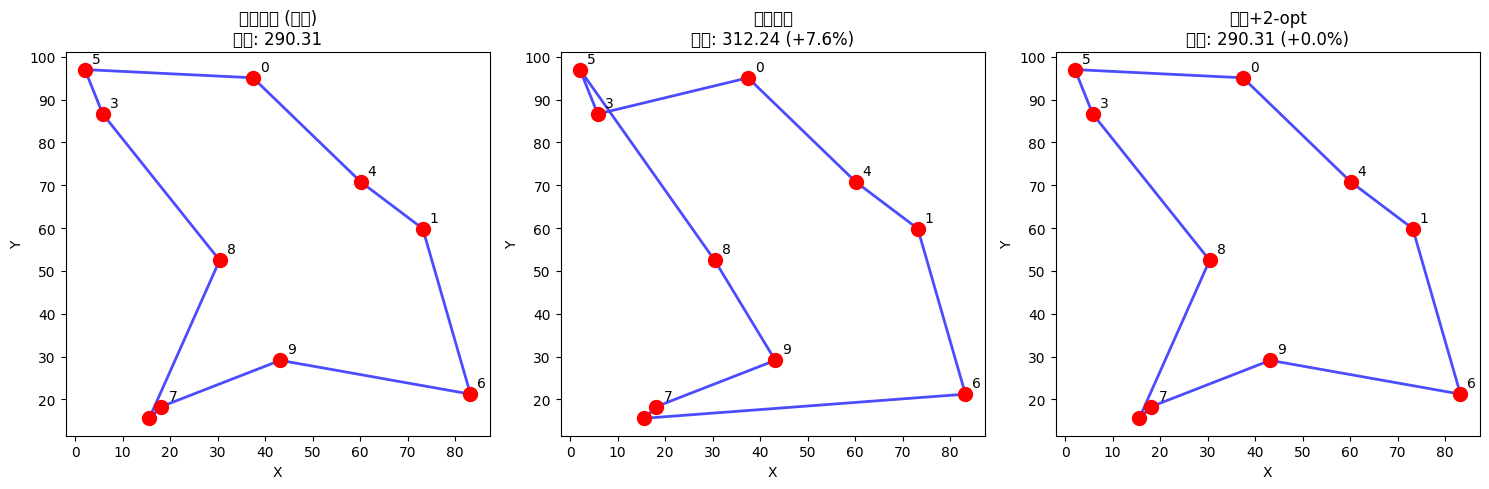

In [28]:
# 可视化不同方法的结果
n = 10
cities = generate_cities(n)

# 计算三种方法的结果
tour_bf, dist_bf = tsp_brute_force(cities)
tour_g, dist_g = tsp_greedy(cities)
tour_2opt, dist_2opt = tsp_2opt(cities, tour_g)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_tour(cities, tour_bf, f"暴力枚举 (最优)\n距离: {dist_bf:.2f}", axes[0])
plot_tour(cities, tour_g, f"贪心算法\n距离: {dist_g:.2f} (+{(dist_g/dist_bf-1)*100:.1f}%)", axes[1])
plot_tour(cities, tour_2opt, f"贪心+2-opt\n距离: {dist_2opt:.2f} (+{(dist_2opt/dist_bf-1)*100:.1f}%)", axes[2])

plt.tight_layout()
plt.show()

### 2.6 TSP 实验的启示

**观察**：
- $n=12$ 时暴力需要数分钟，$n=15$ 需要数小时，$n=20$ 不可行
- 贪心瞬间完成，但有 5-10% 的误差
- 贪心 + 2-opt 几乎瞬间完成，且经常找到最优解！

**核心信息**：
> **利用问题结构**（局部优化）比**暴力搜索**高效得多。这就是优化算法研究的核心：发现并利用结构。

**思考**：为什么 2-opt 这么有效？

因为好的 TSP 解通常**没有交叉**，而 2-opt 正好能消除交叉！

---
## Part 3: GPU vs CPU 性能对比

### 3.1 矩阵乘法对比

矩阵乘法是深度学习的核心操作。让我们比较 CPU 和 GPU 的性能差异。

In [2]:
def benchmark_matmul_numpy(n, num_runs=10):
    """NumPy (CPU) 矩阵乘法"""
    A = np.random.randn(n, n).astype(np.float32)
    B = np.random.randn(n, n).astype(np.float32)

    # 预热
    _ = A @ B

    start = time.time()
    for _ in range(num_runs):
        C = A @ B
    elapsed = (time.time() - start) / num_runs

    gflops = 2 * n**3 / elapsed / 1e9
    return elapsed, gflops

def benchmark_matmul_cupy(n, num_runs=10):
    """CuPy (GPU) 矩阵乘法"""
    if not HAS_GPU:
        return None, None

    A = cp.random.randn(n, n, dtype=cp.float32)
    B = cp.random.randn(n, n, dtype=cp.float32)

    # 预热
    _ = A @ B
    cp.cuda.Stream.null.synchronize()

    start = time.time()
    for _ in range(num_runs):
        C = A @ B
    cp.cuda.Stream.null.synchronize()
    elapsed = (time.time() - start) / num_runs

    gflops = 2 * n**3 / elapsed / 1e9
    return elapsed, gflops

In [3]:
# 运行矩阵乘法对比实验
sizes = [256, 512, 1024, 2048, 4096]
matmul_results = []

print("=" * 65)
print(f"{'Size':>8} | {'CPU (s)':>12} | {'GPU (s)':>12} | {'Speedup':>10}")
print("=" * 65)

for n in sizes:
    cpu_time, cpu_gflops = benchmark_matmul_numpy(n)

    if HAS_GPU:
        gpu_time, gpu_gflops = benchmark_matmul_cupy(n)
        speedup = cpu_time / gpu_time if gpu_time else 0
        print(f"{n:>8} | {cpu_time:>12.6f} | {gpu_time:>12.6f} | {speedup:>9.1f}x")
        matmul_results.append({'size': n, 'cpu_time': cpu_time, 'gpu_time': gpu_time, 'speedup': speedup})
    else:
        print(f"{n:>8} | {cpu_time:>12.6f} | {'N/A':>12} | {'N/A':>10}")
        matmul_results.append({'size': n, 'cpu_time': cpu_time, 'gpu_time': None, 'speedup': None})

print("=" * 65)

    Size |      CPU (s) |      GPU (s) |    Speedup
     256 |     0.000226 |     0.000046 |       4.9x
     512 |     0.000888 |     0.000229 |       3.9x
    1024 |     0.008217 |     0.000188 |      43.6x
    2048 |     0.053485 |     0.001089 |      49.1x
    4096 |     0.255382 |     0.010679 |      23.9x


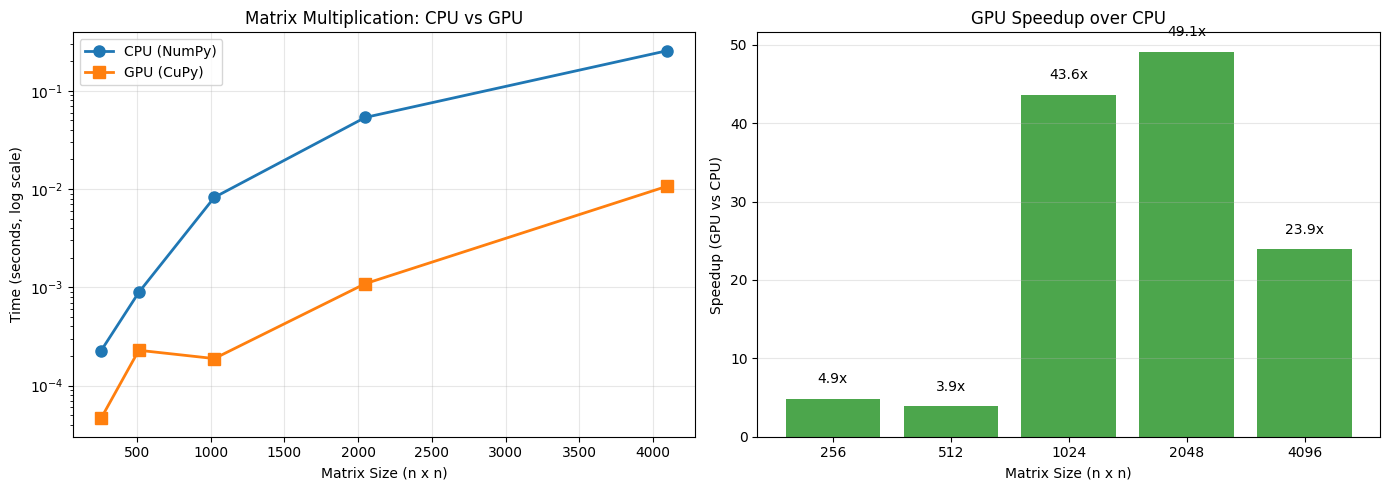

In [4]:
# 可视化矩阵乘法性能对比
if HAS_GPU and matmul_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sizes_plot = [r['size'] for r in matmul_results]
    cpu_times = [r['cpu_time'] for r in matmul_results]
    gpu_times = [r['gpu_time'] for r in matmul_results]
    speedups = [r['speedup'] for r in matmul_results]

    # 时间对比
    axes[0].semilogy(sizes_plot, cpu_times, 'o-', label='CPU (NumPy)', linewidth=2, markersize=8)
    axes[0].semilogy(sizes_plot, gpu_times, 's-', label='GPU (CuPy)', linewidth=2, markersize=8)
    axes[0].set_xlabel('Matrix Size (n x n)')
    axes[0].set_ylabel('Time (seconds, log scale)')
    axes[0].set_title('Matrix Multiplication: CPU vs GPU')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 加速比
    axes[1].bar(range(len(sizes_plot)), speedups, color='green', alpha=0.7)
    axes[1].set_xticks(range(len(sizes_plot)))
    axes[1].set_xticklabels(sizes_plot)
    axes[1].set_xlabel('Matrix Size (n x n)')
    axes[1].set_ylabel('Speedup (GPU vs CPU)')
    axes[1].set_title('GPU Speedup over CPU')
    for i, v in enumerate(speedups):
        axes[1].text(i, v + 2, f'{v:.1f}x', ha='center')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
else:
    print("GPU 不可用，跳过可视化")

### 3.2 向量运算对比

让我们测试一些常见的向量运算在 CPU 和 GPU 上的性能差异。

In [5]:
def benchmark_vector_ops(n, num_runs=100):
    """测试各种向量运算"""
    results = {}

    # CPU
    a_cpu = np.random.randn(n).astype(np.float32)
    b_cpu = np.random.randn(n).astype(np.float32)

    # 加法
    start = time.time()
    for _ in range(num_runs):
        c = a_cpu + b_cpu
    results['cpu_add'] = (time.time() - start) / num_runs

    # 乘法
    start = time.time()
    for _ in range(num_runs):
        c = a_cpu * b_cpu
    results['cpu_mul'] = (time.time() - start) / num_runs

    # 点积
    start = time.time()
    for _ in range(num_runs):
        c = np.dot(a_cpu, b_cpu)
    results['cpu_dot'] = (time.time() - start) / num_runs

    # 范数
    start = time.time()
    for _ in range(num_runs):
        c = np.linalg.norm(a_cpu)
    results['cpu_norm'] = (time.time() - start) / num_runs

    # exp
    start = time.time()
    for _ in range(num_runs):
        c = np.exp(a_cpu)
    results['cpu_exp'] = (time.time() - start) / num_runs

    if HAS_GPU:
        # GPU
        a_gpu = cp.random.randn(n, dtype=cp.float32)
        b_gpu = cp.random.randn(n, dtype=cp.float32)

        # 预热
        _ = a_gpu + b_gpu
        cp.cuda.Stream.null.synchronize()

        # 加法
        start = time.time()
        for _ in range(num_runs):
            c = a_gpu + b_gpu
        cp.cuda.Stream.null.synchronize()
        results['gpu_add'] = (time.time() - start) / num_runs

        # 乘法
        start = time.time()
        for _ in range(num_runs):
            c = a_gpu * b_gpu
        cp.cuda.Stream.null.synchronize()
        results['gpu_mul'] = (time.time() - start) / num_runs

        # 点积
        start = time.time()
        for _ in range(num_runs):
            c = cp.dot(a_gpu, b_gpu)
        cp.cuda.Stream.null.synchronize()
        results['gpu_dot'] = (time.time() - start) / num_runs

        # 范数
        start = time.time()
        for _ in range(num_runs):
            c = cp.linalg.norm(a_gpu)
        cp.cuda.Stream.null.synchronize()
        results['gpu_norm'] = (time.time() - start) / num_runs

        # exp
        start = time.time()
        for _ in range(num_runs):
            c = cp.exp(a_gpu)
        cp.cuda.Stream.null.synchronize()
        results['gpu_exp'] = (time.time() - start) / num_runs

    return results

# 测试不同大小
print("向量运算 CPU vs GPU 对比")
print("=" * 80)

for n in [10_000, 100_000, 1_000_000, 10_000_000]:
    print(f"\n向量大小: {n:,}")
    print("-" * 60)

    results = benchmark_vector_ops(n)

    ops = ['add', 'mul', 'dot', 'norm', 'exp']
    for op in ops:
        cpu_key = f'cpu_{op}'
        gpu_key = f'gpu_{op}'

        if HAS_GPU and gpu_key in results:
            speedup = results[cpu_key] / results[gpu_key]
            print(f"{op:>6}: CPU={results[cpu_key]*1000:.4f}ms, GPU={results[gpu_key]*1000:.4f}ms, Speedup={speedup:.1f}x")
        else:
            print(f"{op:>6}: CPU={results[cpu_key]*1000:.4f}ms, GPU=N/A")

向量运算 CPU vs GPU 对比

向量大小: 10,000
------------------------------------------------------------
   add: CPU=0.0042ms, GPU=0.0162ms, Speedup=0.3x
   mul: CPU=0.0036ms, GPU=1.0187ms, Speedup=0.0x
   dot: CPU=0.0027ms, GPU=1.6621ms, Speedup=0.0x
  norm: CPU=0.0040ms, GPU=1.0574ms, Speedup=0.0x
   exp: CPU=0.0083ms, GPU=1.0152ms, Speedup=0.0x

向量大小: 100,000
------------------------------------------------------------
   add: CPU=0.0420ms, GPU=0.0159ms, Speedup=2.6x
   mul: CPU=0.0403ms, GPU=0.0149ms, Speedup=2.7x
   dot: CPU=0.0113ms, GPU=0.0792ms, Speedup=0.1x
  norm: CPU=0.0102ms, GPU=0.0583ms, Speedup=0.2x
   exp: CPU=0.0698ms, GPU=0.0138ms, Speedup=5.1x

向量大小: 1,000,000
------------------------------------------------------------
   add: CPU=0.5228ms, GPU=0.0158ms, Speedup=33.1x
   mul: CPU=0.5008ms, GPU=0.0153ms, Speedup=32.7x
   dot: CPU=0.3407ms, GPU=0.0788ms, Speedup=4.3x
  norm: CPU=0.1711ms, GPU=0.0761ms, Speedup=2.2x
   exp: CPU=0.6973ms, GPU=0.0203ms, Speedup=34.3x

向量大小: 10,000,

### 3.3 线性方程组求解对比

求解 $Ax = b$ 是科学计算中的核心问题。

In [6]:
def benchmark_linear_solve(n, num_runs=5):
    """测试线性方程组求解"""
    # CPU
    A_cpu = np.random.randn(n, n).astype(np.float32)
    A_cpu = A_cpu @ A_cpu.T + np.eye(n) * n  # 确保正定
    b_cpu = np.random.randn(n).astype(np.float32)

    # 预热
    _ = np.linalg.solve(A_cpu, b_cpu)

    start = time.time()
    for _ in range(num_runs):
        x_cpu = np.linalg.solve(A_cpu, b_cpu)
    cpu_time = (time.time() - start) / num_runs

    if HAS_GPU:
        A_gpu = cp.asarray(A_cpu)
        b_gpu = cp.asarray(b_cpu)

        # 预热
        _ = cp.linalg.solve(A_gpu, b_gpu)
        cp.cuda.Stream.null.synchronize()

        start = time.time()
        for _ in range(num_runs):
            x_gpu = cp.linalg.solve(A_gpu, b_gpu)
        cp.cuda.Stream.null.synchronize()
        gpu_time = (time.time() - start) / num_runs

        return cpu_time, gpu_time

    return cpu_time, None

# 测试线性方程组求解
print("\n线性方程组求解 Ax=b (CPU vs GPU)")
print("=" * 65)
print(f"{'Size':>8} | {'CPU (s)':>12} | {'GPU (s)':>12} | {'Speedup':>10}")
print("=" * 65)

for n in [256, 512, 1024, 2048, 4096]:
    cpu_time, gpu_time = benchmark_linear_solve(n)

    if gpu_time:
        speedup = cpu_time / gpu_time
        print(f"{n:>8} | {cpu_time:>12.6f} | {gpu_time:>12.6f} | {speedup:>9.1f}x")
    else:
        print(f"{n:>8} | {cpu_time:>12.6f} | {'N/A':>12} | {'N/A':>10}")


线性方程组求解 Ax=b (CPU vs GPU)
    Size |      CPU (s) |      GPU (s) |    Speedup
     256 |     0.000887 |     0.000767 |       1.2x
     512 |     0.007399 |     0.002394 |       3.1x
    1024 |     0.032086 |     0.007102 |       4.5x
    2048 |     0.206522 |     0.025990 |       7.9x
    4096 |     1.228680 |     0.140963 |       8.7x


### 3.4 特征值分解对比

特征值分解在 PCA、谱聚类等算法中广泛使用。

In [7]:
def benchmark_eigenvalue(n, num_runs=3):
    """测试特征值分解"""
    # CPU
    A_cpu = np.random.randn(n, n).astype(np.float32)
    A_cpu = A_cpu @ A_cpu.T  # 对称矩阵

    # 预热
    _ = np.linalg.eigh(A_cpu)

    start = time.time()
    for _ in range(num_runs):
        eigenvalues, eigenvectors = np.linalg.eigh(A_cpu)
    cpu_time = (time.time() - start) / num_runs

    if HAS_GPU:
        A_gpu = cp.asarray(A_cpu)

        # 预热
        _ = cp.linalg.eigh(A_gpu)
        cp.cuda.Stream.null.synchronize()

        start = time.time()
        for _ in range(num_runs):
            eigenvalues, eigenvectors = cp.linalg.eigh(A_gpu)
        cp.cuda.Stream.null.synchronize()
        gpu_time = (time.time() - start) / num_runs

        return cpu_time, gpu_time

    return cpu_time, None

# 测试特征值分解
print("\n特征值分解 (CPU vs GPU)")
print("=" * 65)
print(f"{'Size':>8} | {'CPU (s)':>12} | {'GPU (s)':>12} | {'Speedup':>10}")
print("=" * 65)

for n in [256, 512, 1024, 2048]:
    cpu_time, gpu_time = benchmark_eigenvalue(n)

    if gpu_time:
        speedup = cpu_time / gpu_time
        print(f"{n:>8} | {cpu_time:>12.6f} | {gpu_time:>12.6f} | {speedup:>9.1f}x")
    else:
        print(f"{n:>8} | {cpu_time:>12.6f} | {'N/A':>12} | {'N/A':>10}")


特征值分解 (CPU vs GPU)
    Size |      CPU (s) |      GPU (s) |    Speedup
     256 |     0.014512 |     0.002052 |       7.1x
     512 |     0.038087 |     0.004529 |       8.4x
    1024 |     0.173315 |     0.011905 |      14.6x
    2048 |     0.884937 |     0.043741 |      20.2x


### 3.5 批量梯度下降对比

这是深度学习中最核心的操作。让我们模拟一个简单的线性回归梯度下降过程。

In [8]:
def gradient_descent_cpu(X, y, learning_rate=0.01, num_iterations=100):
    """CPU 上的梯度下降"""
    n_samples, n_features = X.shape
    w = np.zeros(n_features, dtype=np.float32)

    for _ in range(num_iterations):
        # 计算预测
        y_pred = X @ w
        # 计算梯度
        gradient = (2 / n_samples) * X.T @ (y_pred - y)
        # 更新权重
        w = w - learning_rate * gradient

    return w

def gradient_descent_gpu(X, y, learning_rate=0.01, num_iterations=100):
    """GPU 上的梯度下降"""
    if not HAS_GPU:
        return None

    n_samples, n_features = X.shape
    X_gpu = cp.asarray(X)
    y_gpu = cp.asarray(y)
    w = cp.zeros(n_features, dtype=cp.float32)

    for _ in range(num_iterations):
        # 计算预测
        y_pred = X_gpu @ w
        # 计算梯度
        gradient = (2 / n_samples) * X_gpu.T @ (y_pred - y_gpu)
        # 更新权重
        w = w - learning_rate * gradient

    cp.cuda.Stream.null.synchronize()
    return cp.asnumpy(w)

# 测试梯度下降
print("\n梯度下降训练 (CPU vs GPU)")
print("=" * 75)
print(f"{'Samples':>10} x {'Features':>8} | {'CPU (s)':>12} | {'GPU (s)':>12} | {'Speedup':>10}")
print("=" * 75)

test_configs = [
    (10000, 100),
    (50000, 100),
    (100000, 100),
    (10000, 1000),
    (50000, 1000),
]

for n_samples, n_features in test_configs:
    X = np.random.randn(n_samples, n_features).astype(np.float32)
    y = np.random.randn(n_samples).astype(np.float32)

    # CPU
    start = time.time()
    w_cpu = gradient_descent_cpu(X, y, num_iterations=100)
    cpu_time = time.time() - start

    # GPU
    if HAS_GPU:
        start = time.time()
        w_gpu = gradient_descent_gpu(X, y, num_iterations=100)
        gpu_time = time.time() - start
        speedup = cpu_time / gpu_time
        print(f"{n_samples:>10} x {n_features:>8} | {cpu_time:>12.4f} | {gpu_time:>12.4f} | {speedup:>9.1f}x")
    else:
        print(f"{n_samples:>10} x {n_features:>8} | {cpu_time:>12.4f} | {'N/A':>12} | {'N/A':>10}")


梯度下降训练 (CPU vs GPU)
   Samples x Features |      CPU (s) |      GPU (s) |    Speedup
     10000 x      100 |       0.0633 |       0.3667 |       0.2x
     50000 x      100 |       0.4499 |       0.0307 |      14.7x
    100000 x      100 |       1.9450 |       0.1152 |      16.9x
     10000 x     1000 |       1.2171 |       0.0700 |      17.4x
     50000 x     1000 |       7.0113 |       0.6952 |      10.1x


### 3.6 PyTorch GPU 对比（如果可用）

使用 PyTorch 进行更实际的深度学习对比。

In [9]:
if HAS_TORCH_GPU:
    print("PyTorch 神经网络前向传播对比")
    print("=" * 65)

    # 定义一个简单的 MLP
    class SimpleMLP(torch.nn.Module):
        def __init__(self, input_size, hidden_size, output_size):
            super().__init__()
            self.fc1 = torch.nn.Linear(input_size, hidden_size)
            self.fc2 = torch.nn.Linear(hidden_size, hidden_size)
            self.fc3 = torch.nn.Linear(hidden_size, output_size)
            self.relu = torch.nn.ReLU()

        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
            x = self.fc3(x)
            return x

    # 测试不同 batch size
    print(f"{'Batch Size':>12} | {'CPU (ms)':>12} | {'GPU (ms)':>12} | {'Speedup':>10}")
    print("-" * 65)

    input_size, hidden_size, output_size = 784, 512, 10

    for batch_size in [32, 128, 512, 2048, 8192]:
        # CPU
        model_cpu = SimpleMLP(input_size, hidden_size, output_size)
        x_cpu = torch.randn(batch_size, input_size)

        # 预热
        _ = model_cpu(x_cpu)

        start = time.time()
        for _ in range(100):
            _ = model_cpu(x_cpu)
        cpu_time = (time.time() - start) / 100 * 1000  # ms

        # GPU
        model_gpu = SimpleMLP(input_size, hidden_size, output_size).cuda()
        x_gpu = torch.randn(batch_size, input_size).cuda()

        # 预热
        _ = model_gpu(x_gpu)
        torch.cuda.synchronize()

        start = time.time()
        for _ in range(100):
            _ = model_gpu(x_gpu)
        torch.cuda.synchronize()
        gpu_time = (time.time() - start) / 100 * 1000  # ms

        speedup = cpu_time / gpu_time
        print(f"{batch_size:>12} | {cpu_time:>12.4f} | {gpu_time:>12.4f} | {speedup:>9.1f}x")
else:
    print("PyTorch GPU 不可用，跳过此测试")

PyTorch 神经网络前向传播对比
  Batch Size |     CPU (ms) |     GPU (ms) |    Speedup
-----------------------------------------------------------------
          32 |       0.6073 |       0.1780 |       3.4x
         128 |       0.6629 |       0.1552 |       4.3x
         512 |       1.5878 |       0.2828 |       5.6x
        2048 |       4.9188 |       0.2668 |      18.4x
        8192 |      24.0903 |       1.3505 |      17.8x


---
## Part 4: 并行算法 vs 顺序算法

### 4.1 前缀和 (Prefix Sum)

前缀和是一个经典例子，展示了并行算法的优势。

In [10]:
def sequential_prefix_sum(arr):
    """顺序前缀和 O(n)，但完全串行"""
    n = len(arr)
    result = np.zeros(n, dtype=arr.dtype)
    result[0] = arr[0]
    for i in range(1, n):
        result[i] = result[i-1] + arr[i]  # 必须等待前一个
    return result

def numpy_cumsum(arr):
    """NumPy 的 cumsum（优化过但仍是 CPU）"""
    return np.cumsum(arr)

# 对比测试
print("前缀和算法对比")
print("=" * 70)

for n in [10000, 100000, 1000000, 10000000]:
    arr = np.random.randn(n).astype(np.float32)

    # 顺序版本（纯 Python）
    if n <= 100000:  # 太大会很慢
        start = time.time()
        _ = sequential_prefix_sum(arr)
        seq_time = time.time() - start
    else:
        seq_time = None

    # NumPy
    start = time.time()
    _ = numpy_cumsum(arr)
    numpy_time = time.time() - start

    # GPU
    if HAS_GPU:
        arr_gpu = cp.asarray(arr)
        # 预热
        _ = cp.cumsum(arr_gpu)
        cp.cuda.Stream.null.synchronize()

        start = time.time()
        _ = cp.cumsum(arr_gpu)
        cp.cuda.Stream.null.synchronize()
        gpu_time = time.time() - start

        speedup = numpy_time / gpu_time
        if seq_time:
            print(f"n={n:>10}: Sequential={seq_time:.4f}s, NumPy={numpy_time:.6f}s, GPU={gpu_time:.6f}s, Speedup={speedup:.1f}x")
        else:
            print(f"n={n:>10}: Sequential=N/A, NumPy={numpy_time:.6f}s, GPU={gpu_time:.6f}s, Speedup={speedup:.1f}x")
    else:
        if seq_time:
            print(f"n={n:>10}: Sequential={seq_time:.4f}s, NumPy={numpy_time:.6f}s")
        else:
            print(f"n={n:>10}: Sequential=N/A, NumPy={numpy_time:.6f}s")

前缀和算法对比
n=     10000: Sequential=0.0034s, NumPy=0.000082s, GPU=0.000180s, Speedup=0.5x
n=    100000: Sequential=0.0328s, NumPy=0.000345s, GPU=0.000079s, Speedup=4.4x
n=   1000000: Sequential=N/A, NumPy=0.003230s, GPU=0.000074s, Speedup=43.8x
n=  10000000: Sequential=N/A, NumPy=0.039426s, GPU=0.000691s, Speedup=57.1x


### 4.2 关键洞察

**顺序算法**：
- 复杂度 $O(n)$
- 需要 $n-1$ 步，每步 1 个操作
- 无法并行化（每一步都依赖前一步）

**并行算法**（Blelloch 算法）：
- 总操作数仍是 $O(n)$
- 只需要 $O(\log n)$ 步
- 每步可以有 $n/2$ 个并行操作

**GPU 优势**：
- GPU 有数千个核心
- 可以同时执行大量并行操作
- 即使总操作数相同，减少步数 = 减少时间

---
## Part 5: 生命游戏 (Conway's Game of Life)

### 5.1 简单规则，复杂行为

生命游戏只有4条规则，却能产生极其复杂的行为，甚至可以模拟图灵机！

**规则**（数一数8个邻居中有多少是活的）：
1. 活细胞，邻居 < 2 → 死（孤独死）
2. 活细胞，邻居 = 2 或 3 → 活（维持）
3. 活细胞，邻居 > 3 → 死（拥挤死）
4. 死细胞，邻居 = 3 → 活（繁殖）

In [11]:
def game_of_life_step_cpu(grid):
    """CPU 版本：生命游戏一步更新"""
    # 使用卷积计算邻居数
    from scipy.ndimage import convolve

    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]])

    neighbors = convolve(grid.astype(np.int32), kernel, mode='wrap')

    # 应用规则
    new_grid = np.zeros_like(grid)
    # 活细胞存活：邻居 = 2 或 3
    new_grid[(grid == 1) & ((neighbors == 2) | (neighbors == 3))] = 1
    # 死细胞繁殖：邻居 = 3
    new_grid[(grid == 0) & (neighbors == 3)] = 1

    return new_grid

def game_of_life_step_gpu(grid_gpu):
    """GPU 版本：生命游戏一步更新"""
    if not HAS_GPU:
        return None

    from cupyx.scipy.ndimage import convolve

    kernel = cp.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]])

    neighbors = convolve(grid_gpu.astype(cp.int32), kernel, mode='wrap')

    # 应用规则
    new_grid = cp.zeros_like(grid_gpu)
    new_grid[(grid_gpu == 1) & ((neighbors == 2) | (neighbors == 3))] = 1
    new_grid[(grid_gpu == 0) & (neighbors == 3)] = 1

    return new_grid

def create_glider(grid, x, y):
    """在 (x, y) 位置创建一个 Glider"""
    glider = np.array([[0, 1, 0],
                       [0, 0, 1],
                       [1, 1, 1]])
    grid[x:x+3, y:y+3] = glider
    return grid

def create_random_grid(size, density=0.3, seed=42):
    """创建随机初始网格"""
    np.random.seed(seed)
    return (np.random.random((size, size)) < density).astype(np.int8)

生命游戏演化示例


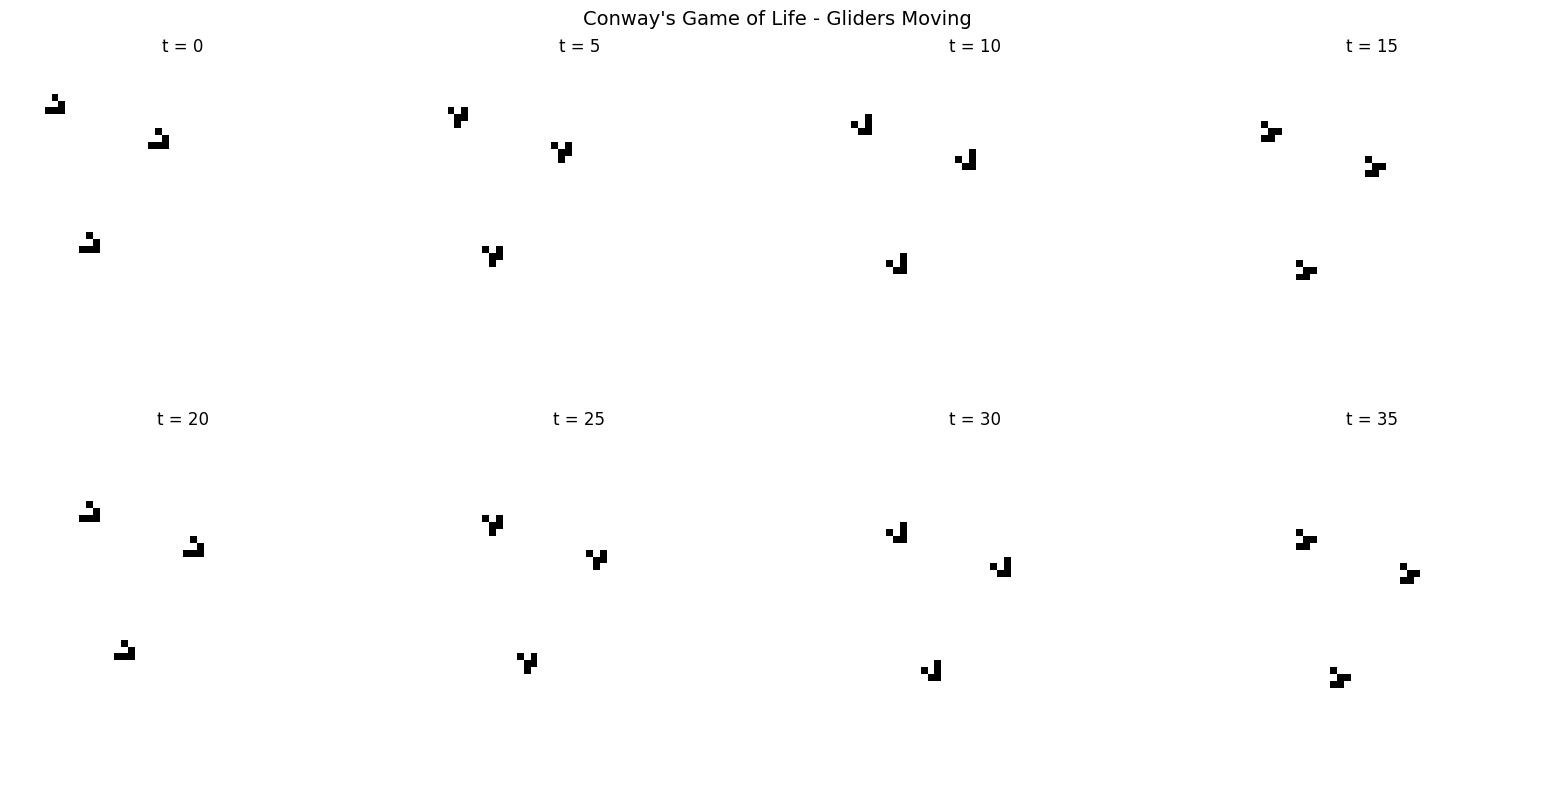

In [12]:
# 可视化生命游戏演化
print("生命游戏演化示例")

# 创建初始网格，添加几个 Glider
size = 50
grid = np.zeros((size, size), dtype=np.int8)
grid = create_glider(grid, 5, 5)
grid = create_glider(grid, 10, 20)
grid = create_glider(grid, 25, 10)

# 演化并显示
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

cmap = ListedColormap(['white', 'black'])

for i, ax in enumerate(axes):
    ax.imshow(grid, cmap=cmap, interpolation='nearest')
    ax.set_title(f't = {i * 5}')
    ax.axis('off')

    # 演化 5 步
    for _ in range(5):
        grid = game_of_life_step_cpu(grid)

plt.suptitle('Conway\'s Game of Life - Gliders Moving', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# 性能对比：CPU vs GPU
print("\n生命游戏 CPU vs GPU 性能对比")
print("=" * 70)
print(f"{'Grid Size':>12} | {'CPU (ms/step)':>15} | {'GPU (ms/step)':>15} | {'Speedup':>10}")
print("=" * 70)

num_steps = 100

for size in [100, 500, 1000, 2000, 4000]:
    grid_cpu = create_random_grid(size)

    # CPU 测试
    start = time.time()
    for _ in range(num_steps):
        grid_cpu = game_of_life_step_cpu(grid_cpu)
    cpu_time = (time.time() - start) / num_steps * 1000  # ms

    if HAS_GPU:
        grid_gpu = cp.asarray(create_random_grid(size))

        # 预热
        _ = game_of_life_step_gpu(grid_gpu)
        cp.cuda.Stream.null.synchronize()

        # GPU 测试
        start = time.time()
        for _ in range(num_steps):
            grid_gpu = game_of_life_step_gpu(grid_gpu)
        cp.cuda.Stream.null.synchronize()
        gpu_time = (time.time() - start) / num_steps * 1000  # ms

        speedup = cpu_time / gpu_time
        print(f"{size}x{size:>5} | {cpu_time:>15.4f} | {gpu_time:>15.4f} | {speedup:>9.1f}x")
    else:
        print(f"{size}x{size:>5} | {cpu_time:>15.4f} | {'N/A':>15} | {'N/A':>10}")


生命游戏 CPU vs GPU 性能对比
   Grid Size |   CPU (ms/step) |   GPU (ms/step) |    Speedup
100x  100 |          0.2805 |          1.0274 |       0.3x
500x  500 |          5.4743 |          1.0482 |       5.2x
1000x 1000 |         21.4862 |          1.1089 |      19.4x
2000x 2000 |         89.1615 |          1.4551 |      61.3x
4000x 4000 |        398.2962 |          5.9201 |      67.3x


### 5.2 生命游戏的启示

1. **简单规则 → 复杂行为**：仅4条规则就能产生图灵完备的系统
2. **天然并行**：每个格子的更新只依赖邻居，所有格子可以同时计算
3. **GPU 优势明显**：随着网格增大，GPU 加速比越来越高

---
## Part 6: 排序算法 GPU vs CPU

### 6.1 找到 GPU 的临界点

GPU 并不总是比 CPU 快！对于小数据，CPU 可能更快。让我们找出临界点。

In [14]:
def benchmark_sort(n, num_runs=10):
    """对比排序性能"""
    # CPU
    arr_cpu = np.random.randn(n).astype(np.float32)

    start = time.time()
    for _ in range(num_runs):
        _ = np.sort(arr_cpu.copy())
    cpu_time = (time.time() - start) / num_runs

    if HAS_GPU:
        arr_gpu = cp.asarray(arr_cpu)

        # 预热
        _ = cp.sort(arr_gpu.copy())
        cp.cuda.Stream.null.synchronize()

        start = time.time()
        for _ in range(num_runs):
            _ = cp.sort(arr_gpu.copy())
        cp.cuda.Stream.null.synchronize()
        gpu_time = (time.time() - start) / num_runs

        return cpu_time, gpu_time

    return cpu_time, None

# 测试不同大小
print("排序算法 CPU vs GPU 性能对比")
print("=" * 70)
print(f"{'Array Size':>15} | {'CPU (ms)':>12} | {'GPU (ms)':>12} | {'Speedup':>10} | {'Winner':>8}")
print("=" * 70)

sizes = [100, 1000, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000]
sort_results = []

for n in sizes:
    cpu_time, gpu_time = benchmark_sort(n)

    if gpu_time:
        speedup = cpu_time / gpu_time
        winner = "GPU" if speedup > 1 else "CPU"
        print(f"{n:>15,} | {cpu_time*1000:>12.4f} | {gpu_time*1000:>12.4f} | {speedup:>9.2f}x | {winner:>8}")
        sort_results.append({'size': n, 'cpu_time': cpu_time, 'gpu_time': gpu_time, 'speedup': speedup})
    else:
        print(f"{n:>15,} | {cpu_time*1000:>12.4f} | {'N/A':>12} | {'N/A':>10} | {'CPU':>8}")

排序算法 CPU vs GPU 性能对比
     Array Size |     CPU (ms) |     GPU (ms) |    Speedup |   Winner
            100 |       0.1762 |       0.0983 |      1.79x |      GPU
          1,000 |       0.0114 |       0.0871 |      0.13x |      CPU
         10,000 |       0.0448 |       0.1187 |      0.38x |      CPU
         50,000 |       0.2163 |       0.1196 |      1.81x |      GPU
        100,000 |       0.4748 |       0.1219 |      3.90x |      GPU
        500,000 |       2.7555 |       0.1337 |     20.61x |      GPU
      1,000,000 |       6.2765 |       0.1655 |     37.92x |      GPU
      5,000,000 |      37.3372 |       0.5844 |     63.89x |      GPU
     10,000,000 |      89.1540 |       1.9323 |     46.14x |      GPU


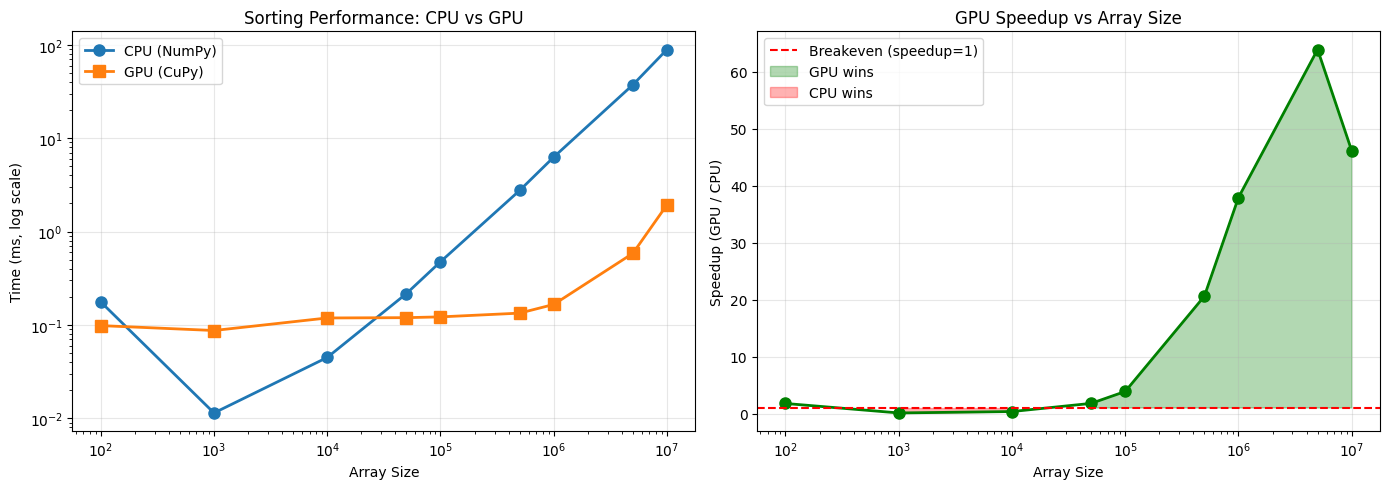


临界点：大约在 10,000,000 到 100 之间
当数组大小 > 100 时，GPU 开始显著占优势


In [15]:
# 可视化排序性能
if HAS_GPU and sort_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sizes_plot = [r['size'] for r in sort_results]
    cpu_times = [r['cpu_time'] * 1000 for r in sort_results]
    gpu_times = [r['gpu_time'] * 1000 for r in sort_results]
    speedups = [r['speedup'] for r in sort_results]

    # 时间对比（对数坐标）
    axes[0].loglog(sizes_plot, cpu_times, 'o-', label='CPU (NumPy)', linewidth=2, markersize=8)
    axes[0].loglog(sizes_plot, gpu_times, 's-', label='GPU (CuPy)', linewidth=2, markersize=8)
    axes[0].set_xlabel('Array Size')
    axes[0].set_ylabel('Time (ms, log scale)')
    axes[0].set_title('Sorting Performance: CPU vs GPU')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 加速比
    axes[1].semilogx(sizes_plot, speedups, 'g-o', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='r', linestyle='--', label='Breakeven (speedup=1)')
    axes[1].fill_between(sizes_plot, speedups, 1, where=[s > 1 for s in speedups],
                         alpha=0.3, color='green', label='GPU wins')
    axes[1].fill_between(sizes_plot, speedups, 1, where=[s <= 1 for s in speedups],
                         alpha=0.3, color='red', label='CPU wins')
    axes[1].set_xlabel('Array Size')
    axes[1].set_ylabel('Speedup (GPU / CPU)')
    axes[1].set_title('GPU Speedup vs Array Size')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 找临界点
    for i, r in enumerate(sort_results):
        if r['speedup'] > 1:
            print(f"\n临界点：大约在 {sort_results[i-1]['size']:,} 到 {r['size']:,} 之间")
            print(f"当数组大小 > {r['size']:,} 时，GPU 开始显著占优势")
            break

### 6.2 为什么小数据 CPU 更快？

1. **数据传输开销**：CPU → GPU 需要通过 PCIe 总线传输数据
2. **核函数启动开销**：GPU 核函数启动有固定开销
3. **GPU 并行度不足**：小数据无法充分利用 GPU 的数千个核心

---
## Part 7: CPU-GPU 数据传输开销

### 7.1 测量传输延迟

理解数据传输开销对于优化 GPU 程序至关重要。

In [16]:
if HAS_GPU:
    print("CPU ↔ GPU 数据传输性能测试")
    print("=" * 75)
    print(f"{'Data Size':>15} | {'CPU→GPU (ms)':>14} | {'GPU→CPU (ms)':>14} | {'Bandwidth':>12}")
    print("=" * 75)

    sizes_bytes = [1024, 10*1024, 100*1024, 1024*1024, 10*1024*1024,
                   100*1024*1024, 500*1024*1024]
    num_runs = 50

    transfer_results = []

    for size_bytes in sizes_bytes:
        n = size_bytes // 4  # float32 = 4 bytes
        arr_cpu = np.random.randn(n).astype(np.float32)

        # CPU → GPU
        cp.cuda.Stream.null.synchronize()
        start = time.time()
        for _ in range(num_runs):
            arr_gpu = cp.asarray(arr_cpu)
            cp.cuda.Stream.null.synchronize()
        h2d_time = (time.time() - start) / num_runs * 1000  # ms

        # GPU → CPU
        cp.cuda.Stream.null.synchronize()
        start = time.time()
        for _ in range(num_runs):
            _ = cp.asnumpy(arr_gpu)
            cp.cuda.Stream.null.synchronize()
        d2h_time = (time.time() - start) / num_runs * 1000  # ms

        # 计算带宽 (GB/s)
        bandwidth = size_bytes / (h2d_time / 1000) / 1e9

        # 格式化大小显示
        if size_bytes >= 1024*1024:
            size_str = f"{size_bytes/1024/1024:.0f} MB"
        else:
            size_str = f"{size_bytes/1024:.0f} KB"

        print(f"{size_str:>15} | {h2d_time:>14.4f} | {d2h_time:>14.4f} | {bandwidth:>10.2f} GB/s")
        transfer_results.append({
            'size_bytes': size_bytes,
            'h2d_time': h2d_time,
            'd2h_time': d2h_time,
            'bandwidth': bandwidth
        })
else:
    print("GPU 不可用，跳过传输测试")

CPU ↔ GPU 数据传输性能测试
      Data Size |   CPU→GPU (ms) |   GPU→CPU (ms) |    Bandwidth
           1 KB |         0.0512 |         0.0171 |       0.02 GB/s
          10 KB |         0.0428 |         0.0196 |       0.24 GB/s
         100 KB |         0.0549 |         0.0450 |       1.86 GB/s
           1 MB |         0.2229 |         0.3049 |       4.70 GB/s
          10 MB |         2.7801 |         2.1500 |       3.77 GB/s
         100 MB |        28.1080 |        37.0482 |       3.73 GB/s
         500 MB |       144.1808 |       184.3941 |       3.64 GB/s


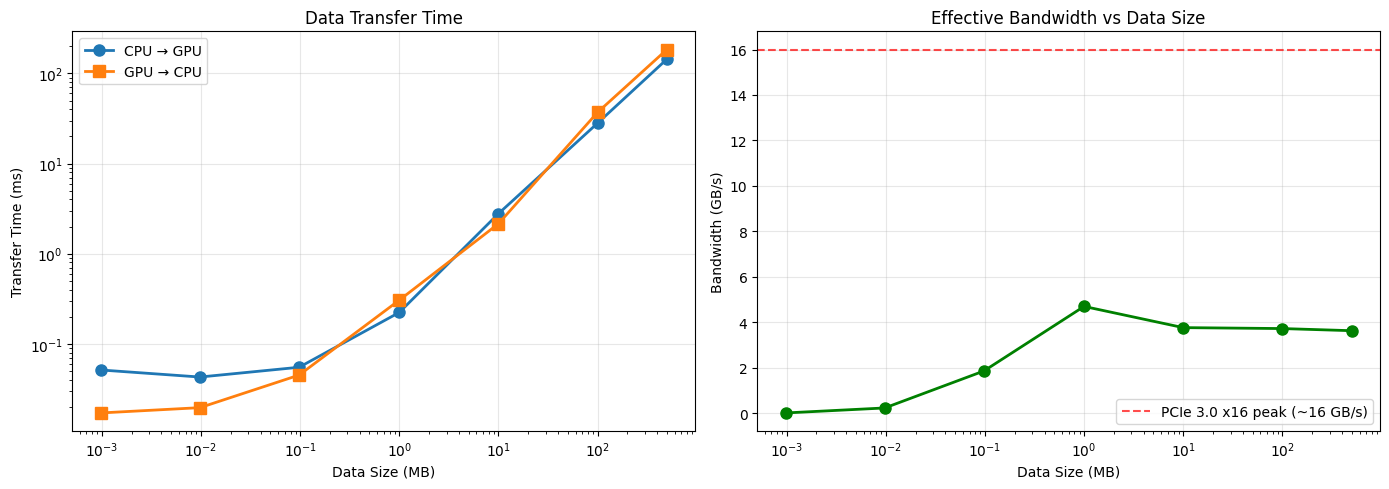


关键观察：
- 小数据传输效率低：1KB 传输带宽仅 0.02 GB/s
- 大数据传输效率高：500MB 传输带宽达 3.64 GB/s
- 启示：尽量批量传输数据，减少传输次数！


In [17]:
if HAS_GPU and transfer_results:
    # 可视化传输性能
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sizes_mb = [r['size_bytes'] / 1024 / 1024 for r in transfer_results]
    h2d_times = [r['h2d_time'] for r in transfer_results]
    d2h_times = [r['d2h_time'] for r in transfer_results]
    bandwidths = [r['bandwidth'] for r in transfer_results]

    # 传输时间
    axes[0].loglog(sizes_mb, h2d_times, 'o-', label='CPU → GPU', linewidth=2, markersize=8)
    axes[0].loglog(sizes_mb, d2h_times, 's-', label='GPU → CPU', linewidth=2, markersize=8)
    axes[0].set_xlabel('Data Size (MB)')
    axes[0].set_ylabel('Transfer Time (ms)')
    axes[0].set_title('Data Transfer Time')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 带宽
    axes[1].semilogx(sizes_mb, bandwidths, 'g-o', linewidth=2, markersize=8)
    axes[1].set_xlabel('Data Size (MB)')
    axes[1].set_ylabel('Bandwidth (GB/s)')
    axes[1].set_title('Effective Bandwidth vs Data Size')
    axes[1].grid(True, alpha=0.3)

    # 添加理论峰值带宽参考线（PCIe 3.0 x16 ≈ 16 GB/s）
    axes[1].axhline(y=16, color='r', linestyle='--', alpha=0.7, label='PCIe 3.0 x16 peak (~16 GB/s)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("\n关键观察：")
    print(f"- 小数据传输效率低：1KB 传输带宽仅 {transfer_results[0]['bandwidth']:.2f} GB/s")
    print(f"- 大数据传输效率高：500MB 传输带宽达 {transfer_results[-1]['bandwidth']:.2f} GB/s")
    print("- 启示：尽量批量传输数据，减少传输次数！")

### 7.2 计算 vs 传输的权衡

In [18]:
if HAS_GPU:
    print("\n计算 vs 传输时间对比")
    print("=" * 80)
    print("问题：什么时候值得把数据传到 GPU 计算？")
    print("=" * 80)

    n = 1000000  # 100万元素，约 4MB
    arr_cpu = np.random.randn(n).astype(np.float32)

    # 测量传输时间
    start = time.time()
    arr_gpu = cp.asarray(arr_cpu)
    cp.cuda.Stream.null.synchronize()
    transfer_time = (time.time() - start) * 1000

    # 测量不同计算的时间
    operations = [
        ('向量加法 (a+b)', lambda: arr_cpu + arr_cpu, lambda: arr_gpu + arr_gpu),
        ('向量乘法 (a*b)', lambda: arr_cpu * arr_cpu, lambda: arr_gpu * arr_gpu),
        ('求和 sum(a)', lambda: np.sum(arr_cpu), lambda: cp.sum(arr_gpu)),
        ('exp(a)', lambda: np.exp(arr_cpu), lambda: cp.exp(arr_gpu)),
        ('排序 sort(a)', lambda: np.sort(arr_cpu.copy()), lambda: cp.sort(arr_gpu.copy())),
    ]

    print(f"\n数据大小: {n:,} 元素 ({n*4/1024/1024:.1f} MB)")
    print(f"传输时间 (CPU→GPU): {transfer_time:.4f} ms")
    print("-" * 80)
    print(f"{'Operation':>20} | {'CPU (ms)':>12} | {'GPU (ms)':>12} | {'Break-even':>15}")
    print("-" * 80)

    for name, cpu_op, gpu_op in operations:
        # CPU
        start = time.time()
        for _ in range(10):
            _ = cpu_op()
        cpu_time = (time.time() - start) / 10 * 1000

        # GPU (不含传输)
        _ = gpu_op()  # 预热
        cp.cuda.Stream.null.synchronize()
        start = time.time()
        for _ in range(10):
            _ = gpu_op()
        cp.cuda.Stream.null.synchronize()
        gpu_time = (time.time() - start) / 10 * 1000

        # 计算 break-even：需要多少次运算才能抵消传输开销
        if cpu_time > gpu_time:
            break_even = transfer_time / (cpu_time - gpu_time)
            break_even_str = f"{break_even:.1f} ops"
        else:
            break_even_str = "Never (CPU faster)"

        print(f"{name:>20} | {cpu_time:>12.4f} | {gpu_time:>12.4f} | {break_even_str:>15}")

    print("\n结论：")
    print("- 简单操作（加法、乘法）需要多次运算才能抵消传输开销")
    print("- 复杂操作（排序、exp）较少次数就能抵消传输开销")
    print("- 最佳策略：把数据保留在 GPU 上，连续进行多次计算！")
else:
    print("GPU 不可用，跳过此测试")


计算 vs 传输时间对比
问题：什么时候值得把数据传到 GPU 计算？

数据大小: 1,000,000 元素 (3.8 MB)
传输时间 (CPU→GPU): 1.2846 ms
--------------------------------------------------------------------------------
           Operation |     CPU (ms) |     GPU (ms) |      Break-even
--------------------------------------------------------------------------------
          向量加法 (a+b) |       0.5062 |       0.0213 |         2.6 ops
          向量乘法 (a*b) |       0.3598 |       0.0185 |         3.8 ops
           求和 sum(a) |       0.2782 |       0.0270 |         5.1 ops
              exp(a) |       0.6744 |       0.0180 |         2.0 ops
          排序 sort(a) |       6.3519 |       0.1708 |         0.2 ops

结论：
- 简单操作（加法、乘法）需要多次运算才能抵消传输开销
- 复杂操作（排序、exp）较少次数就能抵消传输开销
- 最佳策略：把数据保留在 GPU 上，连续进行多次计算！


---
## Part 8: 蒙特卡洛方法

### 8.1 用随机采样估计 π

蒙特卡洛方法具有天然的并行性：每次采样相互独立，非常适合 GPU。

In [19]:
def estimate_pi_cpu(n_samples):
    """CPU 版本：蒙特卡洛估计 π"""
    x = np.random.uniform(-1, 1, n_samples).astype(np.float32)
    y = np.random.uniform(-1, 1, n_samples).astype(np.float32)

    inside_circle = np.sum(x**2 + y**2 <= 1)
    pi_estimate = 4 * inside_circle / n_samples

    return pi_estimate

def estimate_pi_gpu(n_samples):
    """GPU 版本：蒙特卡洛估计 π"""
    if not HAS_GPU:
        return None

    x = cp.random.uniform(-1, 1, n_samples, dtype=cp.float32)
    y = cp.random.uniform(-1, 1, n_samples, dtype=cp.float32)

    inside_circle = cp.sum(x**2 + y**2 <= 1)
    pi_estimate = 4 * float(inside_circle) / n_samples

    return pi_estimate

# 测试不同采样数
print("蒙特卡洛估计 π - CPU vs GPU")
print("=" * 85)
print(f"{'Samples':>15} | {'π estimate':>12} | {'Error':>12} | {'CPU (ms)':>12} | {'GPU (ms)':>12} | {'Speedup':>8}")
print("=" * 85)

true_pi = np.pi

for n in [100000, 1000000, 10000000, 100000000]:
    # CPU
    start = time.time()
    pi_cpu = estimate_pi_cpu(n)
    cpu_time = (time.time() - start) * 1000

    error = abs(pi_cpu - true_pi)

    if HAS_GPU:
        # 预热
        _ = estimate_pi_gpu(10000)
        cp.cuda.Stream.null.synchronize()

        start = time.time()
        pi_gpu = estimate_pi_gpu(n)
        cp.cuda.Stream.null.synchronize()
        gpu_time = (time.time() - start) * 1000

        speedup = cpu_time / gpu_time
        print(f"{n:>15,} | {pi_cpu:>12.8f} | {error:>12.8f} | {cpu_time:>12.2f} | {gpu_time:>12.2f} | {speedup:>7.1f}x")
    else:
        print(f"{n:>15,} | {pi_cpu:>12.8f} | {error:>12.8f} | {cpu_time:>12.2f} | {'N/A':>12} | {'N/A':>8}")

print(f"\n真实 π 值: {true_pi:.10f}")

蒙特卡洛估计 π - CPU vs GPU
        Samples |   π estimate |        Error |     CPU (ms) |     GPU (ms) |  Speedup
        100,000 |   3.14420000 |   0.00260735 |         2.56 |         0.65 |     3.9x
      1,000,000 |   3.14510800 |   0.00351535 |        21.89 |         0.51 |    42.9x
     10,000,000 |   3.14165600 |   0.00006335 |       237.25 |         2.32 |   102.1x
    100,000,000 |   3.14163888 |   0.00004623 |      2664.09 |        31.20 |    85.4x

真实 π 值: 3.1415926536


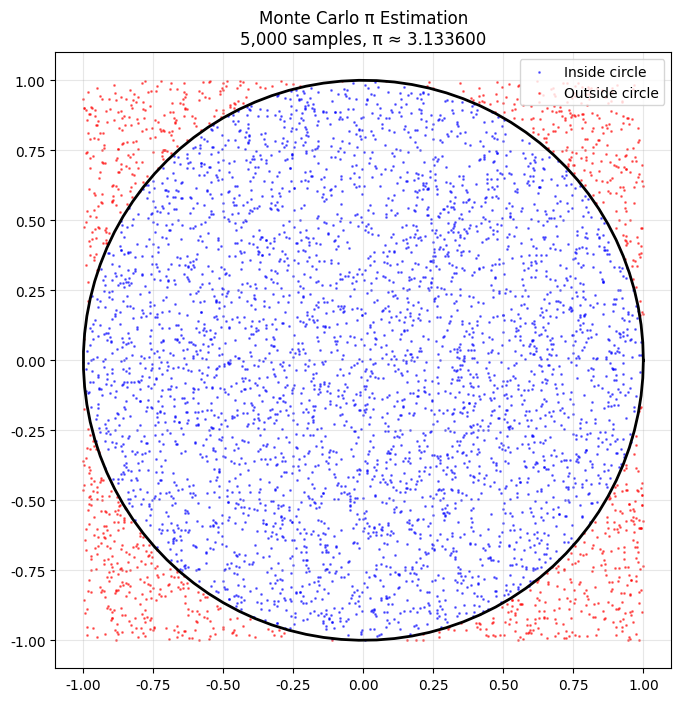

In [20]:
# 可视化蒙特卡洛方法
np.random.seed(42)
n_vis = 5000
x = np.random.uniform(-1, 1, n_vis)
y = np.random.uniform(-1, 1, n_vis)
inside = x**2 + y**2 <= 1

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x[inside], y[inside], c='blue', s=1, alpha=0.5, label='Inside circle')
ax.scatter(x[~inside], y[~inside], c='red', s=1, alpha=0.5, label='Outside circle')

# 画单位圆
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)

pi_estimate = 4 * np.sum(inside) / n_vis
ax.set_title(f'Monte Carlo π Estimation\n{n_vis:,} samples, π ≈ {pi_estimate:.6f}')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 8.2 模拟退火解 TSP

模拟退火是一种随机优化方法，可以跳出局部最优。

In [29]:
def simulated_annealing_tsp(cities, initial_temp=1000, cooling_rate=0.995,
                            num_iterations=10000):
    """模拟退火解 TSP"""
    n = len(cities)

    # 初始解：随机排列
    current_tour = list(range(n))
    np.random.shuffle(current_tour)
    current_dist = total_distance(current_tour, cities)

    best_tour = current_tour.copy()
    best_dist = current_dist

    temp = initial_temp
    history = [current_dist]

    for iteration in range(num_iterations):
        # 随机选择两个位置交换
        i, j = np.random.choice(n, 2, replace=False)

        # 生成邻居解
        new_tour = current_tour.copy()
        new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
        new_dist = total_distance(new_tour, cities)

        # 计算接受概率
        delta = new_dist - current_dist
        if delta < 0 or np.random.random() < np.exp(-delta / temp):
            current_tour = new_tour
            current_dist = new_dist

            if current_dist < best_dist:
                best_tour = current_tour.copy()
                best_dist = current_dist

        # 降温
        temp *= cooling_rate

        if iteration % 100 == 0:
            history.append(current_dist)

    return best_tour, best_dist, history

# 运行模拟退火
print("模拟退火解 TSP")
print("=" * 50)

n_cities = 20
cities = generate_cities(n_cities, seed=123)

# 贪心 + 2-opt 基准
start = time.time()
tour_g, dist_g = tsp_greedy(cities)
tour_2opt, dist_2opt = tsp_2opt(cities, tour_g)
time_2opt = time.time() - start
print(f"贪心+2-opt: 距离={dist_2opt:.2f}, 时间={time_2opt:.4f}s")

# 模拟退火
start = time.time()
tour_sa, dist_sa, history = simulated_annealing_tsp(cities, num_iterations=50000)
time_sa = time.time() - start
print(f"模拟退火:   距离={dist_sa:.2f}, 时间={time_sa:.4f}s")

improvement = (dist_2opt - dist_sa) / dist_2opt * 100
print(f"\n模拟退火比 2-opt {'好' if improvement > 0 else '差'} {abs(improvement):.2f}%")

模拟退火解 TSP
贪心+2-opt: 距离=341.78, 时间=0.0660s
模拟退火:   距离=411.69, 时间=5.2547s

模拟退火比 2-opt 差 20.46%


/tmp/ipython-input-3242869307.py:20: UserWarning: Glyph 36138 (\N{CJK UNIFIED IDEOGRAPH-8D2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3242869307.py:20: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3242869307.py:20: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3242869307.py:20: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3242869307.py:20: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3242869307.py:20: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3242869307.py:20: UserWarning: Glyph 36864 (\N{CJK UNIFIED IDEOGRAPH-9000}) missi

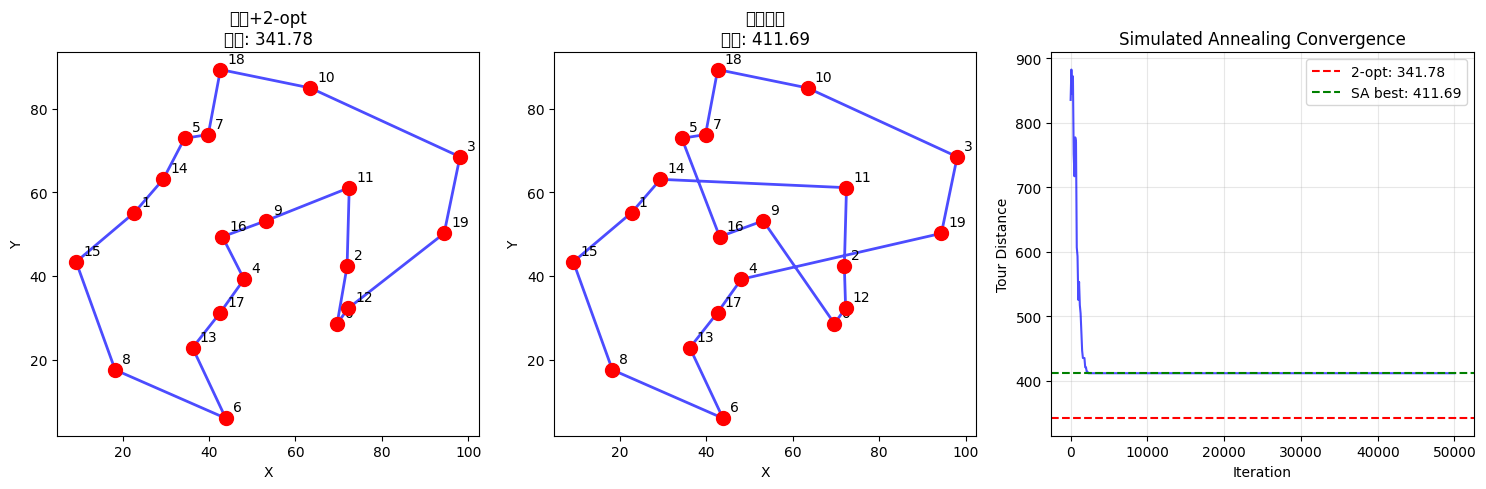

In [30]:
# 可视化模拟退火过程
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2-opt 结果
plot_tour(cities, tour_2opt, f"贪心+2-opt\n距离: {dist_2opt:.2f}", axes[0])

# 模拟退火结果
plot_tour(cities, tour_sa, f"模拟退火\n距离: {dist_sa:.2f}", axes[1])

# 收敛曲线
axes[2].plot(range(0, len(history)*100, 100), history, 'b-', alpha=0.7)
axes[2].axhline(y=dist_2opt, color='r', linestyle='--', label=f'2-opt: {dist_2opt:.2f}')
axes[2].axhline(y=dist_sa, color='g', linestyle='--', label=f'SA best: {dist_sa:.2f}')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Tour Distance')
axes[2].set_title('Simulated Annealing Convergence')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 9: Batch Size 对 GPU 效率的影响

### 9.1 为什么大 Batch 更高效？

在深度学习中，增大 batch size 可以显著提高 GPU 利用率。让我们量化这个效果。

In [31]:
if HAS_TORCH_GPU:
    print("Batch Size 对 GPU 效率的影响")
    print("=" * 80)

    # 定义一个更大的模型
    class LargerMLP(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.layers = torch.nn.Sequential(
                torch.nn.Linear(784, 1024),
                torch.nn.ReLU(),
                torch.nn.Linear(1024, 1024),
                torch.nn.ReLU(),
                torch.nn.Linear(1024, 512),
                torch.nn.ReLU(),
                torch.nn.Linear(512, 10)
            )

        def forward(self, x):
            return self.layers(x)

    model = LargerMLP().cuda()

    # 测试不同 batch size
    batch_sizes = [1, 4, 16, 64, 256, 1024, 4096]
    results = []

    print(f"{'Batch Size':>12} | {'Time/sample (μs)':>18} | {'Throughput (samples/s)':>22} | {'GPU Util':>10}")
    print("-" * 80)

    for batch_size in batch_sizes:
        x = torch.randn(batch_size, 784).cuda()

        # 预热
        for _ in range(10):
            _ = model(x)
        torch.cuda.synchronize()

        # 计时
        num_runs = 100
        start = time.time()
        for _ in range(num_runs):
            _ = model(x)
        torch.cuda.synchronize()
        elapsed = time.time() - start

        time_per_sample = elapsed / (num_runs * batch_size) * 1e6  # μs
        throughput = num_runs * batch_size / elapsed

        # 计算相对于最大 batch 的 GPU 利用率
        results.append({
            'batch_size': batch_size,
            'time_per_sample': time_per_sample,
            'throughput': throughput
        })

    max_throughput = max(r['throughput'] for r in results)

    for r in results:
        gpu_util = r['throughput'] / max_throughput * 100
        print(f"{r['batch_size']:>12} | {r['time_per_sample']:>18.2f} | {r['throughput']:>22,.0f} | {gpu_util:>9.1f}%")

    print("\n观察：")
    print(f"- Batch size=1 时，每个样本处理时间: {results[0]['time_per_sample']:.2f} μs")
    print(f"- Batch size=4096 时，每个样本处理时间: {results[-1]['time_per_sample']:.2f} μs")
    print(f"- 效率提升: {results[0]['time_per_sample'] / results[-1]['time_per_sample']:.1f}x")
else:
    print("PyTorch GPU 不可用，跳过此测试")

Batch Size 对 GPU 效率的影响
  Batch Size |   Time/sample (μs) | Throughput (samples/s) |   GPU Util
--------------------------------------------------------------------------------
           1 |             220.55 |                  4,534 |       0.2%
           4 |              52.75 |                 18,956 |       0.9%
          16 |              13.20 |                 75,772 |       3.4%
          64 |               3.42 |                292,684 |      13.2%
         256 |               0.85 |              1,181,273 |      53.2%
        1024 |               0.45 |              2,220,666 |     100.0%
        4096 |               0.63 |              1,597,713 |      71.9%

观察：
- Batch size=1 时，每个样本处理时间: 220.55 μs
- Batch size=4096 时，每个样本处理时间: 0.63 μs
- 效率提升: 352.4x


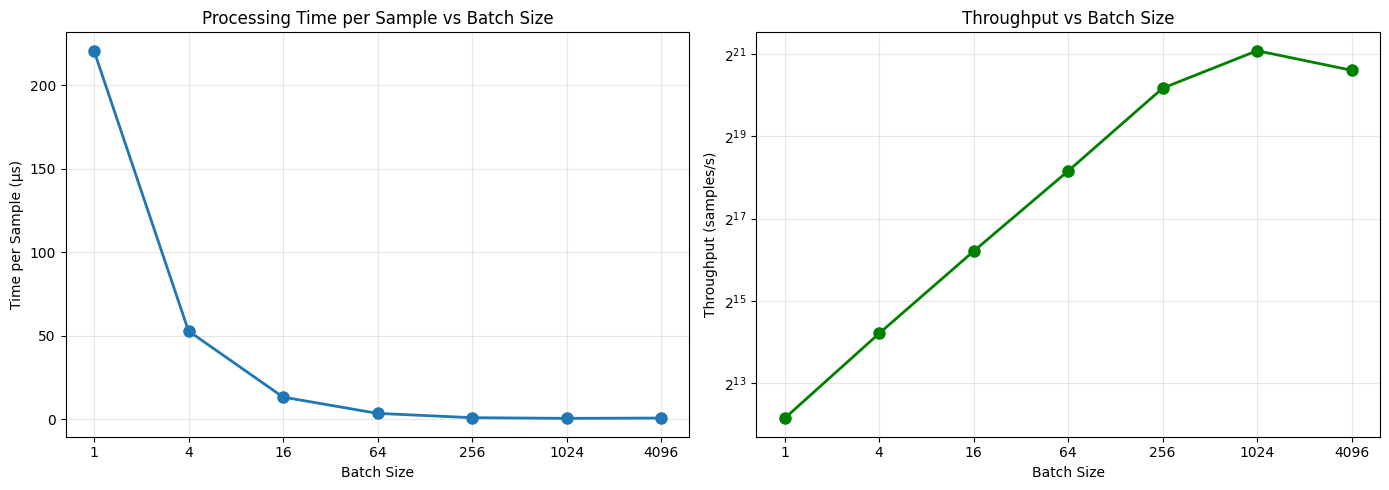

In [32]:
if HAS_TORCH_GPU and results:
    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    batch_sizes_plot = [r['batch_size'] for r in results]
    time_per_sample = [r['time_per_sample'] for r in results]
    throughputs = [r['throughput'] for r in results]

    # 每样本时间
    axes[0].semilogx(batch_sizes_plot, time_per_sample, 'o-', linewidth=2, markersize=8, base=2)
    axes[0].set_xlabel('Batch Size')
    axes[0].set_ylabel('Time per Sample (μs)')
    axes[0].set_title('Processing Time per Sample vs Batch Size')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(batch_sizes_plot)
    axes[0].set_xticklabels(batch_sizes_plot)

    # 吞吐量
    axes[1].loglog(batch_sizes_plot, throughputs, 'g-o', linewidth=2, markersize=8, base=2)
    axes[1].set_xlabel('Batch Size')
    axes[1].set_ylabel('Throughput (samples/s)')
    axes[1].set_title('Throughput vs Batch Size')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(batch_sizes_plot)
    axes[1].set_xticklabels(batch_sizes_plot)

    plt.tight_layout()
    plt.show()

### 9.2 为什么大 Batch 更高效？

1. **核函数启动开销**：每次 GPU 操作有固定开销，大 batch 可以摊薄
2. **内存带宽利用**：大 batch 可以更好地利用 GPU 内存带宽
3. **计算并行度**：大 batch 可以充分利用 GPU 的数千个核心
4. **流水线效率**：大 batch 让 GPU 的流水线保持忙碌

**深度学习启示**：
- 训练时尽量用大 batch（受限于显存）
- 推理时也应该批量处理
- 小 batch 会严重浪费 GPU 性能

---
## Part 10: 总结

### 本周核心信息

1. **计算有边界**
   - 停机问题不可判定
   - 某些数学命题可能永远无法证明

2. **NP-完全问题**
   - 暴力枚举复杂度爆炸
   - 利用问题结构可以高效求解
   - "足够好" 的解往往比 "最优解" 更实际

3. **GPU 范式转变**
   - GPU 在矩阵运算上比 CPU 快 10-100+ 倍
   - 并行度是关键因素
   - 算法设计要考虑硬件特性

4. **GPU 使用要点**
   - 小数据不一定适合 GPU（传输开销）
   - 尽量批量传输、批量计算
   - 大 batch size 显著提高效率

5. **简单规则 → 复杂行为**
   - 生命游戏只有4条规则却图灵完备
   - 随机方法（蒙特卡洛、模拟退火）非常适合并行化

6. **理论 vs 实践**
   - $O(n \log n)$ 理论最优 ≠ 实际最快
   - 简单+并行 可能优于 复杂+串行
   - GPU 时代需要重新思考算法设计

---
## 思考题

1. 设计一个图灵机，判断输入的二进制数是否为偶数。（提示：只需要看最后一位）

2. 以下哪些问题是 NP-Complete 的？
   - (a) 判断一个图是否有欧拉回路
   - (b) 判断一个图是否有哈密顿回路
   - (c) 找到图的最大匹配
   - (d) 找到图的最大独立集

3. 为什么 GPU 上的矩阵乘法不用 Strassen 算法？

4. 凸优化问题是 P 还是 NP？为什么这对深度学习很重要？

5. 设计一个实验，比较在你的电脑上 CPU 顺序排序和 GPU 并行排序的性能。在什么规模下 GPU 开始占优势？（本 notebook 已包含此实验）

6. 在生命游戏实验中，为什么网格越大 GPU 加速比越高？

7. 如果你需要处理 1000 个独立的小矩阵乘法（每个 100x100），应该怎么在 GPU 上高效实现？